# Predicting "Choose your track"

We train four classifiers on the survey answers in `Responses.csv` to predict the track each student chose:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest

The notebook covers:

- **Data quality:** remove rows with random answers (the biggest accuracy gain) and duplicate rows (so the test scores are honest).
- **Training:** tune each model's hyperparameters with 5-fold cross-validation on the training set.
- **Evaluation:** confusion matrix, accuracy, precision, recall and F1-score on a held-out test set, plus cross-validation accuracy to check that the scores are stable and the models do not overfit.
- **Analysis:** where the remaining errors come from and which questions matter most.

In [1]:
import re
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import ( RandomForestClassifier)

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.model_selection import ( GridSearchCV,StratifiedKFold, cross_val_score, cross_val_predict, train_test_split)

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

TARGET = "Choose your track"

cv = StratifiedKFold( n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pd.set_option("display.max_colwidth", None)

## 1. Load the data

In [2]:
df = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\App folder\\NTI project\\Responses.csv")
print("Shape:", df.shape)
df.head()

Shape: (8416, 20)


,Unnamed: 0,Choose your track,1- What is your current level expertise in computer programming?,2- How often do you code or work on tech related projects in your free time?,3- How often do you keep up with tech news and trends?,4- Were you willing to learn and work with programming languages?,"5- Was your choice based on enjoying working with visual elements, such as layout and design?","7- Did you have interest in analyzing and studying user's behavior , needs and challenges?",8- Did you have a strong background in mathematics and enjoyed solving complex mathematical problems?,9-Did you enjoy working with data to solve real world problems?,10- Were you interested in data research and analysis?,11- Were you passionate about data analysis and deriving insights from data sets?,12- Did you have interest in using algorithms that can learn and improve from data?,13- Were you interested in server-side programming and building the backbone of applications?,14- Did you have interest in creating innovative and creative software?,15- Was you choice based on using mobile apps frequently and having ideas for new ones?,16- Were you concerned about the security of digital systems and data?,"17- Did you enjoy learning about encryption, firewalls and network protection",18- Did you enjoy creative problem-solving and design thinking?,6- Did you have interest creating responsive and interactive web pages
0,NaN,Front-end,Intermediate,Weekly,Weekly,Yes,Yes,yes,No,No,No,No,No,No,Yes,No,No,No,Yes,Yes
1,NaN,Front-end,Beginner,Weekly,Weekly,Yes,Yes,No,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,No,Yes,Yes
2,NaN,Back-end,Expert,Daily,Weekly,Yes,No,No,No,No,Yes,No,No,Yes,Yes,No,Yes,Yes,No,Yes
3,NaN,UI/UX,Intermediate,Weekly,Daily,No,Yes,yes,No,No,No,No,No,No,No,No,No,No,No,No
4,NaN,Data Science,Beginner,Daily,Daily,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,No,No,No,Yes,No


## 2. Clean the data

The first column has no header and is completely empty, so we drop it.

The question headers are long, so we rename them to `Q1` … `Q18` using the number at the start of each question. The CSV lists question 6 last, so we also put the columns back in order.

In [3]:
df = df.drop(columns=["Unnamed: 0"])

short_names = {col: "Q" + re.match(r"\d+", col).group() for col in df.columns if col != TARGET}
question_cols = sorted(short_names.values(), key=lambda q: int(q[1:]))
df = df.rename(columns=short_names)[[TARGET] + question_cols]

# Reference table: short name -> full question
question_text = pd.Series({short: full for full, short in short_names.items()}, name="Question")[question_cols]
question_text.to_frame()

,Question
Q1,1- What is your current level expertise in computer programming?
Q2,2- How often do you code or work on tech related projects in your free time?
Q3,3- How often do you keep up with tech news and trends?
Q4,4- Were you willing to learn and work with programming languages?
Q5,"5- Was your choice based on enjoying working with visual elements, such as layout and design?"
Q6,6- Did you have interest creating responsive and interactive web pages
Q7,"7- Did you have interest in analyzing and studying user's behavior , needs and challenges?"
Q8,8- Did you have a strong background in mathematics and enjoyed solving complex mathematical problems?
Q9,9-Did you enjoy working with data to solve real world problems?
Q10,10- Were you interested in data research and analysis?


In [4]:
print("Missing values:", df.isna().sum().sum())
df[TARGET].value_counts()

Missing values: 0


Choose your track
Back-end               1267
UI/UX                  1222
Front-end              1208
Mobile applications    1196
Cyber Security         1185
Data Science           1178
Machine Learning       1160
Name: count, dtype: int64

### Is the data balanced?

The 7 tracks are close to evenly sized (largest class / smallest class ≈ 1.09:1 in the raw data, ≈1.23:1 after cleaning). That is a **mild** imbalance, well under the ~1.5–2:1 rule of thumb where resampling (SMOTE, class weights) becomes necessary. `train_test_split(..., stratify=y)` already keeps the same class proportions in train/test, so **no further balancing is applied** — doing so on data this even would only add synthetic noise.

Class counts:
 Choose your track
Back-end               1267
UI/UX                  1222
Front-end              1208
Mobile applications    1196
Cyber Security         1185
Data Science           1178
Machine Learning       1160
Name: count, dtype: int64

Max/Min ratio: 1.09 : 1  ->  considered balanced if < ~1.5:1


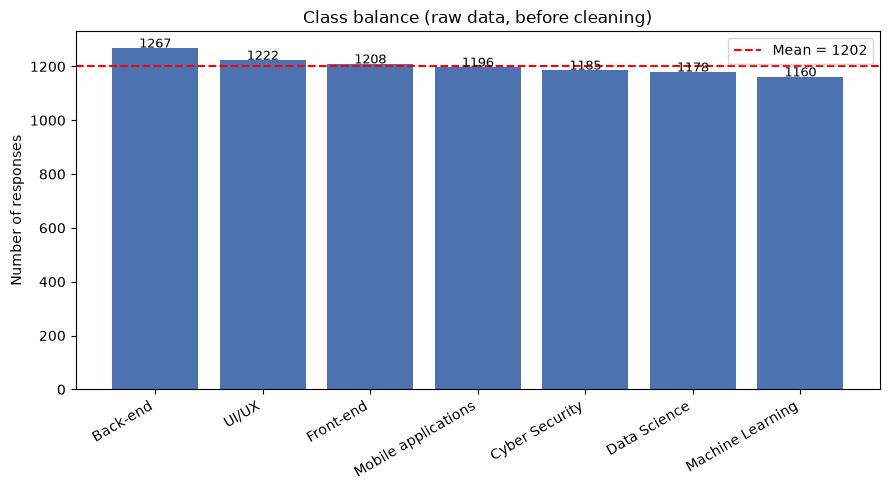

In [5]:
import matplotlib.pyplot as plt

counts = df[TARGET].value_counts()
ratio = counts.max() / counts.min()
print("Class counts:\n", counts)
print(f"\nMax/Min ratio: {ratio:.2f} : 1  ->  considered balanced if < ~1.5:1")

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(counts.index, counts.values, color="#4C72B0")
ax.axhline(counts.mean(), color="red", linestyle="--", label=f"Mean = {counts.mean():.0f}")
ax.set_title("Class balance (raw data, before cleaning)")
ax.set_ylabel("Number of responses")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend()
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, str(int(b.get_height())), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Encode the answers as numbers

The models need numeric inputs. Every answer has a natural order, so we map each one to an integer:

- **Q1** (programming level): Beginner = 0, Intermediate = 1, Expert = 2
- **Q2, Q3** (how often): Never = 0, Rarely = 1, Monthly = 2, Weekly = 3, Daily = 4
- **Q4–Q18** (Yes/No): No = 0, Yes = 1. Q7 is written as lowercase `yes`, so we lowercase all answers before mapping.

In [6]:
level = {"Beginner": 0, "Intermediate": 1, "Expert": 2}
frequency = {"Never": 0, "Rarely": 1, "Monthly": 2, "Weekly": 3, "Daily": 4}
yes_no = {"no": 0, "yes": 1}

df["Q1"] = df["Q1"].map(level)
df["Q2"] = df["Q2"].map(frequency)
df["Q3"] = df["Q3"].map(frequency)
for col in question_cols[3:]:
    df[col] = df[col].str.strip().str.lower().map(yes_no)

# An answer that is not in the dictionaries above would turn into NaN.
assert df[question_cols].notna().all().all(), "Found an answer that is not in the mappings"
df.head()

,Choose your track,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18
0,Front-end,1,3,3,1,1,1,1,0,0,0,0,0,0,1,0,0,0,1
1,Front-end,0,3,3,1,1,1,0,1,1,0,0,1,1,1,0,1,0,1
2,Back-end,2,4,3,1,0,1,0,0,0,1,0,0,1,1,0,1,1,0
3,UI/UX,1,3,4,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
4,Data Science,0,4,4,1,0,0,0,1,1,1,1,0,0,0,0,0,0,1


## 4. Remove rows with random answers

Two blocks of rows do not look like real survey answers: **rows 5,554–6,039 and 7,870–8,415**, 1,032 rows in total. Row numbers are the DataFrame index, which starts at 0; add 2 to get the row number in Excel. The blocks were found by checking how well each row's answers fit its track. The next two cells show the evidence.

**Evidence 1: every question looks like a coin flip.** Inside the blocks, every Yes/No question is answered "Yes" about half the time. In the rest of the file the share of "Yes" changes a lot from question to question.

In [7]:
RANDOM_BLOCKS = [(5554, 6039), (7870, 8415)]

in_blocks = np.zeros(len(df), dtype=bool)
for start, end in RANDOM_BLOCKS:
    in_blocks |= (df.index >= start) & (df.index <= end)
print("Rows in the blocks:", in_blocks.sum())

# Share of "Yes" answers per question
pd.DataFrame({
    "Rest of the file": df.loc[~in_blocks, question_cols[3:]].mean(),
    "Random blocks": df.loc[in_blocks, question_cols[3:]].mean(),
}).T.round(2)

Rows in the blocks: 1032


,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18
Rest of the file,0.85,0.35,0.42,0.39,0.37,0.29,0.14,0.28,0.16,0.33,0.33,0.19,0.18,0.25,0.56
Random blocks,0.49,0.51,0.53,0.50,0.48,0.53,0.50,0.49,0.22,0.47,0.49,0.50,0.51,0.48,0.51


**Evidence 2: the answers say nothing about the track.** Cross-validation gives every unique row a prediction from a model that never saw that row. Before and between the blocks the predictions are mostly correct. Inside the blocks they are right about as often as guessing one of the 7 tracks at random (1/7 ≈ 14%).

In [8]:
unique_rows = df.drop_duplicates()
predicted = cross_val_predict(
    LogisticRegression(max_iter=3000), unique_rows[question_cols], unique_rows[TARGET], cv=cv
)
correct = pd.Series(predicted == unique_rows[TARGET].values, index=unique_rows.index)

windows = {
    "Before block 1 (rows 5,254-5,553)": (5254, 5553),
    "Block 1 (rows 5,554-6,039)": (5554, 6039),
    "Between the blocks (rows 6,040-7,869)": (6040, 7869),
    "Block 2 (rows 7,870-8,415)": (7870, 8415),
}
pd.DataFrame(
    [
        {"Part of the file": name, "Unique rows": correct.loc[start:end].size, "Accuracy": correct.loc[start:end].mean()}
        for name, (start, end) in windows.items()
    ]
).set_index("Part of the file").round(3)

,Unique rows,Accuracy
Part of the file,,
"Before block 1 (rows 5,254-5,553)",257,0.961
"Block 1 (rows 5,554-6,039)",486,0.134
"Between the blocks (rows 6,040-7,869)",258,0.938
"Block 2 (rows 7,870-8,415)",546,0.136


No model can predict a track from answers that carry no information about it. These rows only add noise to training and pull every test score down, so we remove them.

In [9]:
df = df[~in_blocks]
print("Rows left:", len(df))

Rows left: 7384


## 5. Remove duplicate rows

Most of the remaining rows are exact copies of another row (same answers and same track), and some responses appear up to 30 times. If we keep the copies, the same response ends up in both the training set and the test set. The models are then graded on answers they have already seen, and the test scores come out higher than they would be on new responses.

We keep one copy of each response. The index keeps the original row numbers, so we can still tell where each row came from in the file.

In [10]:
print("Rows before:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Most copies of a single response:", df.value_counts().max())

df = df.drop_duplicates()
print("Rows after:", len(df))
df[TARGET].value_counts()

Rows before: 7384
Duplicate rows: 5089
Most copies of a single response: 30
Rows after: 2295


Choose your track
Back-end               376
Mobile applications    349
UI/UX                  331
Machine Learning       316
Data Science           313
Front-end              305
Cyber Security         305
Name: count, dtype: int64

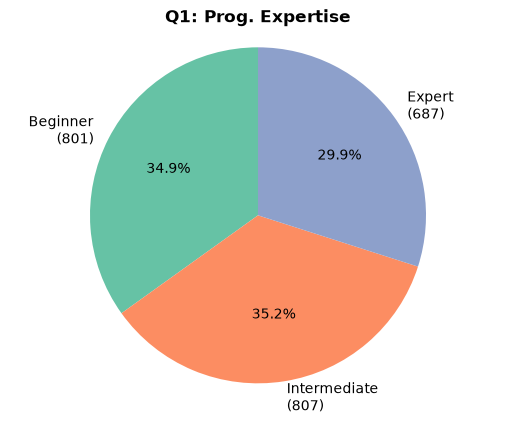

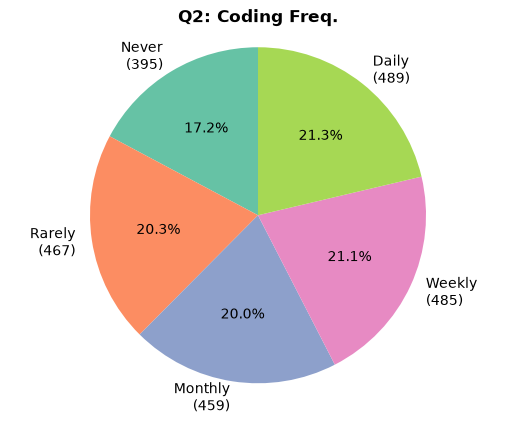

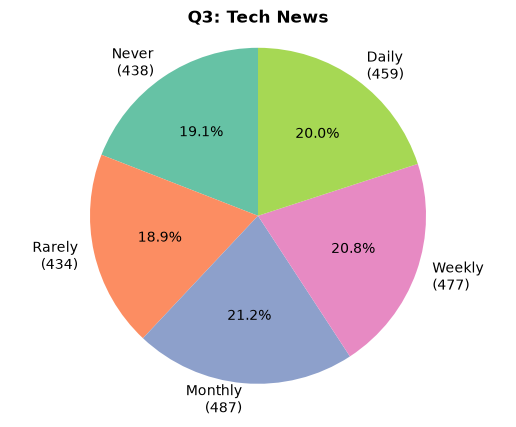

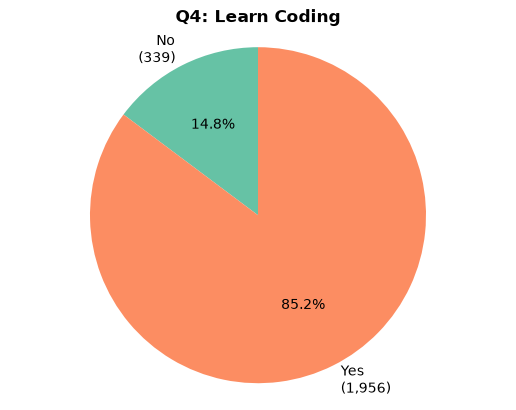

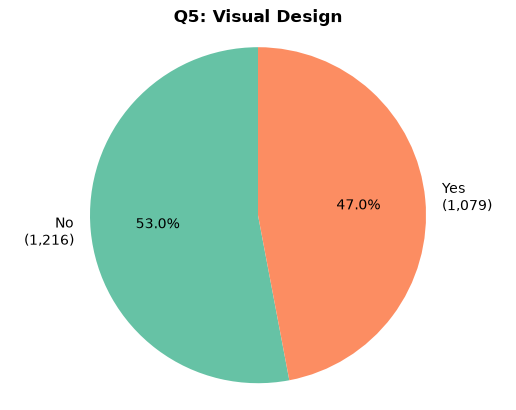

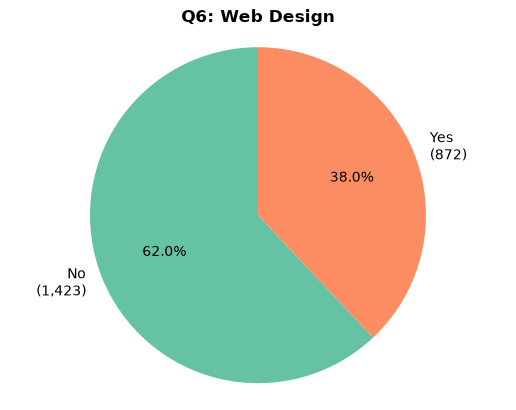

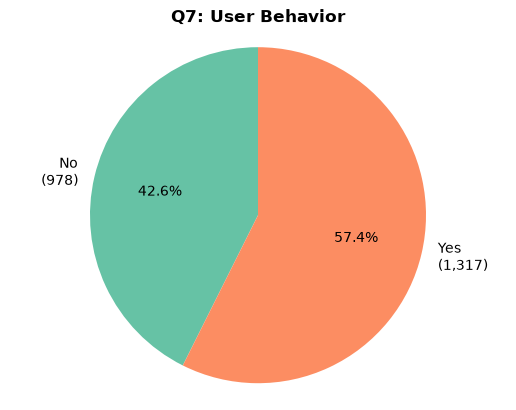

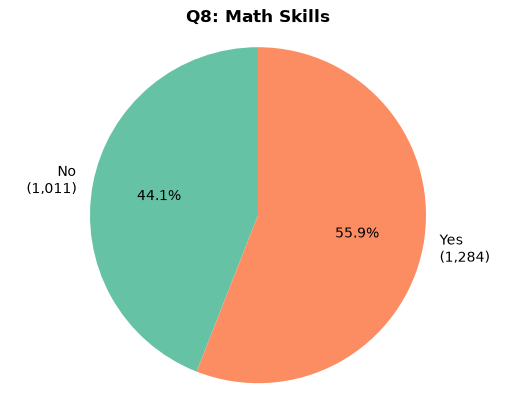

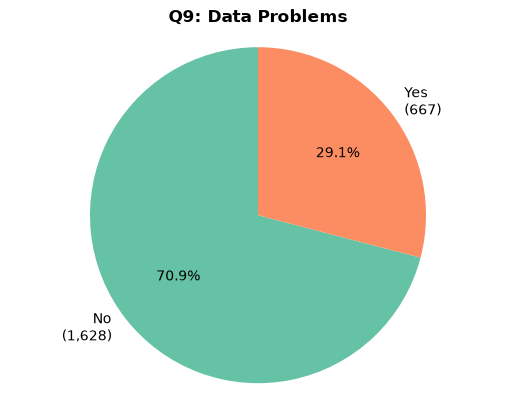

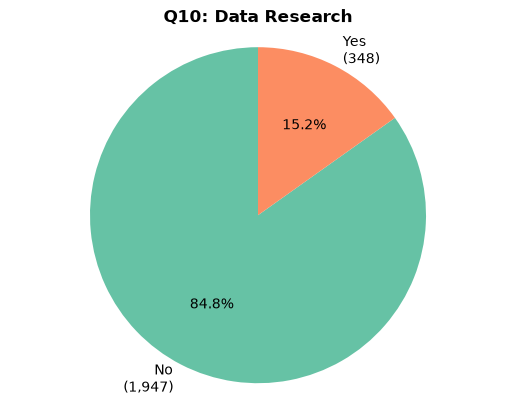

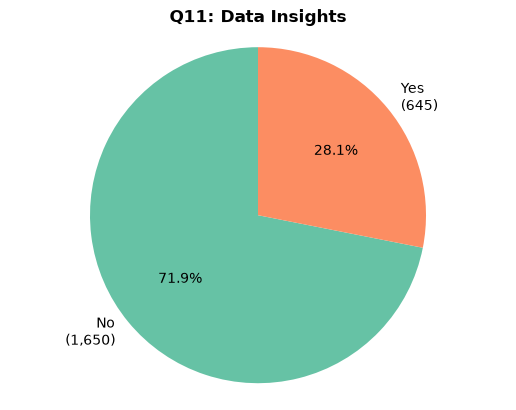

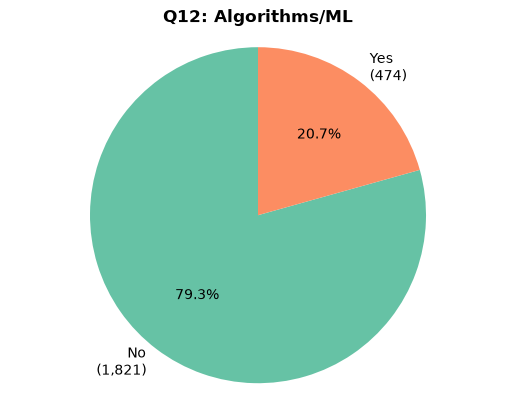

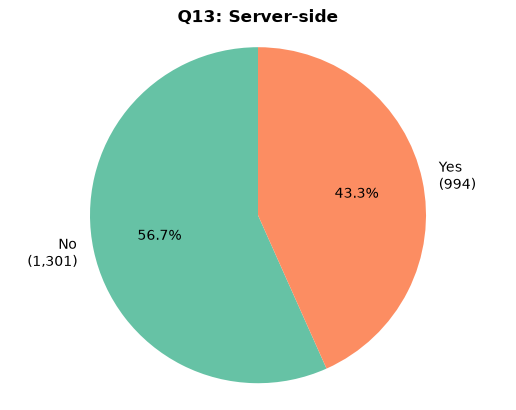

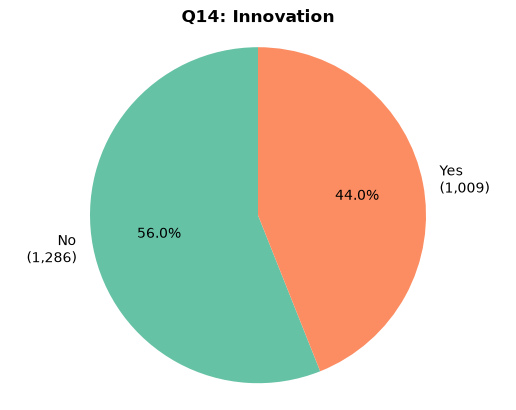

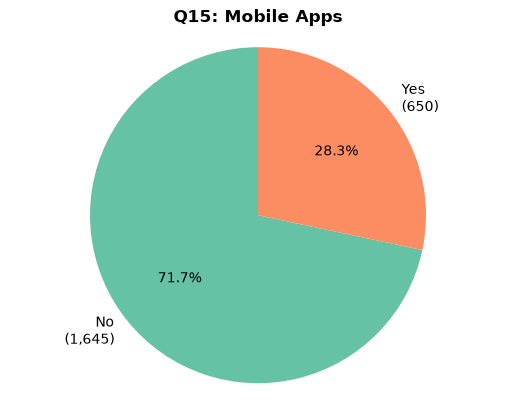

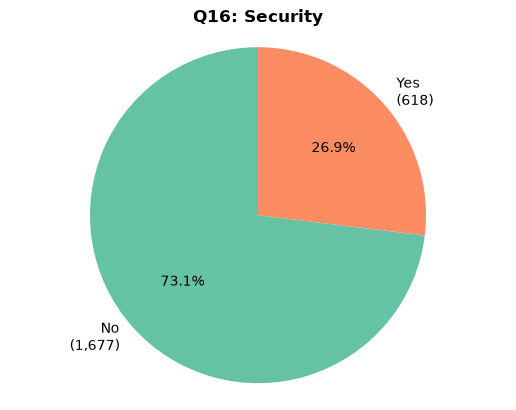

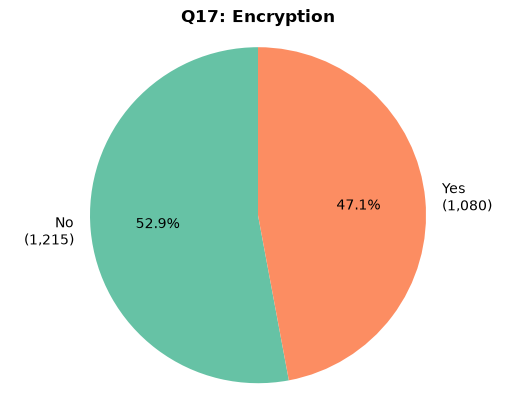

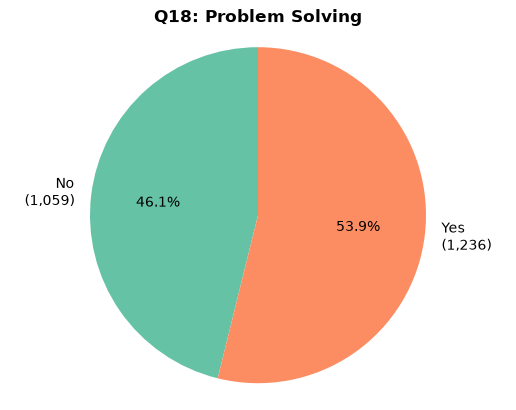

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

SHORT_LABELS = {
    "Q1":  "Prog. Expertise",
    "Q2":  "Coding Freq.",
    "Q3":  "Tech News",
    "Q4":  "Learn Coding",
    "Q5":  "Visual Design",
    "Q6":  "Web Design",
    "Q7":  "User Behavior",
    "Q8":  "Math Skills",
    "Q9":  "Data Problems",
    "Q10": "Data Research",
    "Q11": "Data Insights",
    "Q12": "Algorithms/ML",
    "Q13": "Server-side",
    "Q14": "Innovation",
    "Q15": "Mobile Apps",
    "Q16": "Security",
    "Q17": "Encryption",
    "Q18": "Problem Solving",
}

INVERSE_Q1 = {0: 'Beginner', 1: 'Intermediate', 2: 'Expert'}
INVERSE_Q2 = {0: 'Never', 1: 'Rarely', 2: 'Monthly', 3: 'Weekly', 4: 'Daily'}
INVERSE_Q3 = INVERSE_Q2
INVERSE    = {0: 'No', 1: 'Yes'}

INVERSE_MAPS = {
    "Q1": INVERSE_Q1,
    "Q2": INVERSE_Q2,
    "Q3": INVERSE_Q3,
}
for q in [f"Q{i}" for i in range(4, 19)]:
    INVERSE_MAPS[q] = INVERSE
  

def plot_pie(df, col, inverse_maps, short_labels, figsize=(6, 6)):
  counts = df[col].value_counts().sort_index()
  inv = inverse_maps.get(col, {})
  labels = [f"{inv.get(int(k), str(k))}\n({v:,})" for k, v in counts.items()]
  title = f"{col}: {short_labels.get(col, col)}"

  plt.pie(
        counts.values, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("Set2", len(counts)),
        textprops=dict(fontsize=10),
    )
  plt.title(title, fontsize=12, fontweight='bold')
  plt.axis('equal')
  plt.show()

input = df.drop('Choose your track', axis=1)
for col in input:
  plot_pie(input, col, INVERSE_MAPS, SHORT_LABELS)

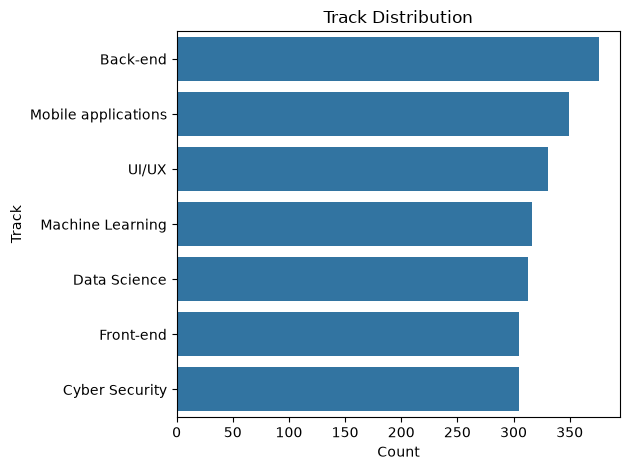

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

order = df['Choose your track'].value_counts().index

sns.countplot(
    data=df,
    y='Choose your track',  
    order=order,             
)
plt.title('Track Distribution')
plt.xlabel('Count')
plt.ylabel('Track')
plt.tight_layout()
plt.show()

## 6. Split into training and test sets

80% of the rows are used for training and 20% are held back for testing. `stratify=y` keeps the same share of each track in both sets.

In [14]:
X = df[question_cols]
y = df[TARGET]

mapping = {
    'Back-end': 0,
    'Cyber Security': 1,
    'Data Science': 2,
    'Front-end': 3,
    'Machine Learning': 4,
    'Mobile applications': 5,
    'UI/UX': 6
}

y = y.map(mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (1836, 18)
Test:  (459, 18)


## 7. Build the models using Pipelines

From this point onward, every model is built inside a `Pipeline`.  
We reuse the best hyperparameters already identified in the previous tuning work where possible, so we do not run another large `GridSearchCV`.

Because the features are already encoded as numeric values:
- Logistic Regression, SVM and KNN use `StandardScaler`.
- Decision Tree and tree/ensemble models do **not** need scaling.


## 8. Define all model Pipelines

The parameters below are fixed from the previous tuning stage to save execution time.

In [15]:
models = {
    "Decision Tree": Pipeline([
            ("model", DecisionTreeClassifier(
                max_depth=5,
                random_state=RANDOM_STATE
            ))
        ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.01, max_iter=5000))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=5,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

print("Models:", ", ".join(models.keys()))


Models: Decision Tree, Logistic Regression, Random Forest


## 9. Train the models

Each model is fitted through its Pipeline, so the preprocessing step (such as scaling) is automatically applied only where needed.

In [16]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("\nAll models trained successfully.")


Training Decision Tree...
Training Logistic Regression...
Training Random Forest...

All models trained successfully.


## 10. Evaluate all models

We use the same metrics for the multiclass classification problem: Accuracy, Macro Precision, Macro Recall and Macro F1-score. We also calculate 5-fold cross-validation accuracy on the training set.

In [17]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1-score": f1_score(y_test, y_pred, average="macro")
    })

summary = pd.DataFrame(results).sort_values(
    "CV Accuracy", ascending=False
).reset_index(drop=True)

summary.round(4)


,Model,CV Accuracy,CV Std,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,0.9417,0.0070,0.9586,0.9622,0.9615,0.9607
1,Logistic Regression,0.9374,0.0069,0.9477,0.9513,0.9508,0.9503
2,Decision Tree,0.9063,0.0116,0.9063,0.9324,0.9150,0.9107


## 11. Classification reports

The report below shows the performance of every model for each track separately.

In [18]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test, y_pred, digits=4))


Decision Tree
              precision    recall  f1-score   support

           0     0.9762    0.5467    0.7009        75
           1     1.0000    0.9672    0.9833        61
           2     0.9683    0.9683    0.9683        63
           3     0.9672    0.9672    0.9672        61
           4     0.9841    0.9841    0.9841        63
           5     0.6602    0.9714    0.7861        70
           6     0.9706    1.0000    0.9851        66

    accuracy                         0.9063       459
   macro avg     0.9324    0.9150    0.9107       459
weighted avg     0.9292    0.9063    0.9032       459

Logistic Regression
              precision    recall  f1-score   support

           0     0.9265    0.8400    0.8811        75
           1     1.0000    0.9836    0.9917        61
           2     0.9254    0.9841    0.9538        63
           3     0.9672    0.9672    0.9672        61
           4     1.0000    0.9524    0.9756        63
           5     0.8553    0.9286    0.8904 

## 12. Confusion matrices

Rows represent the actual track and columns represent the predicted track.

In [19]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=model.classes_),
        index=pd.Index(model.classes_, name="Actual"),
        columns=pd.Index(model.classes_, name="Predicted")
    )

    print(f"\n{name}")
    display(cm)



Decision Tree


Predicted,0,1,2,3,4,5,6
Actual,,,,,,,
0,41,0,0,0,1,33,0
1,0,59,0,0,0,2,0
2,1,0,61,0,0,0,1
3,0,0,1,59,0,0,1
4,0,0,1,0,62,0,0
5,0,0,0,2,0,68,0
6,0,0,0,0,0,0,66



Logistic Regression


Predicted,0,1,2,3,4,5,6
Actual,,,,,,,
0,63,0,1,0,0,11,0
1,1,60,0,0,0,0,0
2,1,0,62,0,0,0,0
3,0,0,1,59,0,0,1
4,0,0,3,0,60,0,0
5,3,0,0,2,0,65,0
6,0,0,0,0,0,0,66



Random Forest


Predicted,0,1,2,3,4,5,6
Actual,,,,,,,
0,63,0,0,0,1,11,0
1,1,60,0,0,0,0,0
2,1,0,62,0,0,0,0
3,0,0,1,59,0,0,1
4,0,0,1,0,62,0,0
5,0,0,0,2,0,68,0
6,0,0,0,0,0,0,66


## 13. Best model

The best model is selected using cross-validation accuracy, not the test set.

In [20]:
best_name = summary.loc[0, "Model"]
best_model = models[best_name]

print("Best model by CV accuracy:", best_name)
print("\nBest model test performance:")
best_pred = best_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_test, best_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_test, best_pred, average='macro'):.4f}")


Best model by CV accuracy: Random Forest

Best model test performance:
Accuracy : 0.9586
Precision: 0.9622
Recall   : 0.9615
F1-score : 0.9607


## 14. Model Accuracy Comparison

This graph compares the Cross-Validation Accuracy and Test Accuracy of the different models.

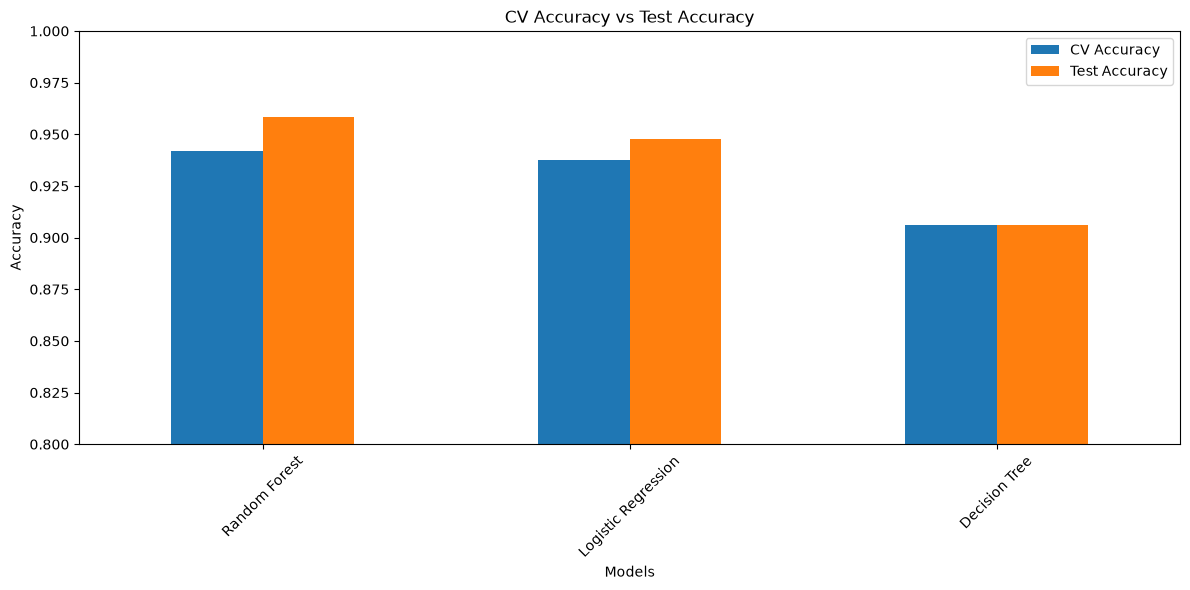

In [21]:
import matplotlib.pyplot as plt

summary.plot(
    x='Model',
    y=['CV Accuracy', 'Test Accuracy'],
    kind='bar',
    figsize=(12, 6)
)

plt.title('CV Accuracy vs Test Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()